# Honeycomb Tight-Binding Model

Let's setup the problem class using the honeycomb data json.

In [1]:
from acceptor_TI import Problem

data_path = "../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [2]:
hopping_dict = problem.cell_parser.eigenvalues.nn_hopping.value
hopping_dict["t_ss_sigma"] = -1.4
hopping_dict["t_sp_sigma"] = 1
hopping_dict["t_pp_sigma"] = 2
hopping_dict["t_pp_pi"] = -3

In [3]:
location = "edge"
problem.setup(
    N_r = 10,            # size of lattice in real space
    N_k = 300,           # reciprocal space discretization
    location = location  # location of where to calculate eigenvalues
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


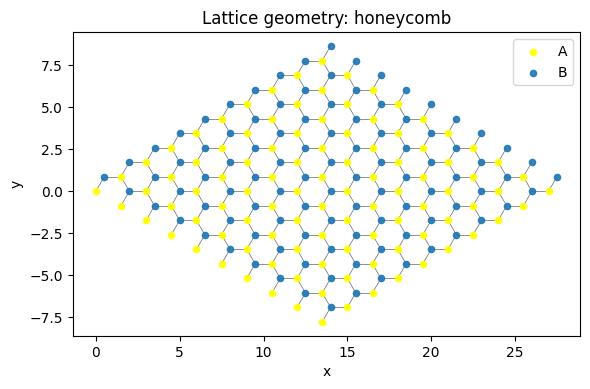

In [4]:
problem.plot(plot_type="lattice")

## Clebsch-Gordan Coefficients

In [5]:
tb = problem.Hamiltonian[location]["tight_binding"] # Bulk

tb.CG_coefficients

{'|0,0;0.5,-0.5>': 0.707106781186548*sqrt(2),
 '|0,0;0.5,0.5>': 0.707106781186548*sqrt(2),
 '|1,-1;0.5,-0.5>': 1.00000000000000,
 '|1,-1;0.5,0.5>': 0.333333333333333*sqrt(3),
 '|1,0;0.5,-0.5>': 0.333333333333333*sqrt(6),
 '|1,0;0.5,0.5>': 0.333333333333333*sqrt(6),
 '|1,1;0.5,-0.5>': 0.333333333333333*sqrt(3),
 '|1,1;0.5,0.5>': 1.00000000000000}

In [6]:
tb.sublattice_data_dict["A"].keys()
sublattice = list(tb.sublattice_data_dict["A"].keys())[0]

## Coupled Angular Momentum States

In [7]:
if location == "bulk":
    idx = tb.sublattice_data_dict["A"]["neighbour_idxs"][1]
    tb.sublattice_data_dict["A"]['coupled_states_dict'][idx]
elif location == "edge":
    idx = tb.sublattice_data_dict["A"][sublattice]["neighbour_idxs"][0]
    tb.sublattice_data_dict["A"][sublattice]['hopping_dict'][idx]

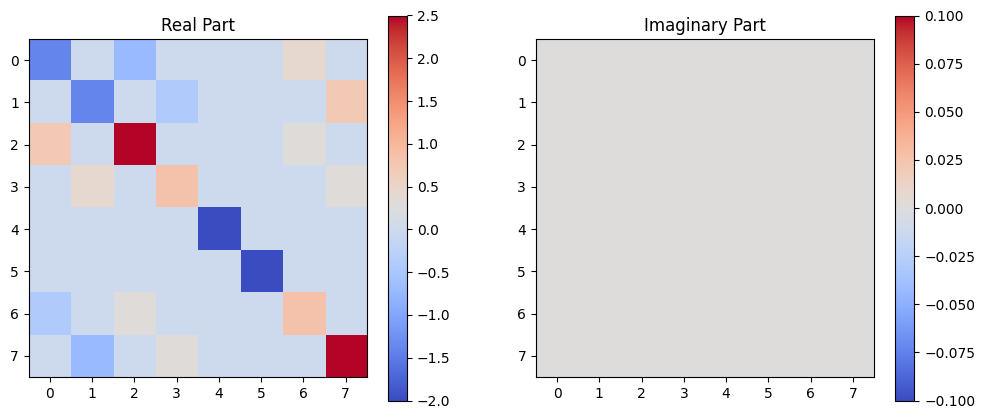

In [8]:
if location == "bulk":
    tb._visualise_matrix(tb.sublattice_data_dict["A"]['hopping_dict'][idx])
elif location == "edge":
    tb._visualise_matrix(tb.sublattice_data_dict["A"][sublattice]['hopping_dict'][idx])

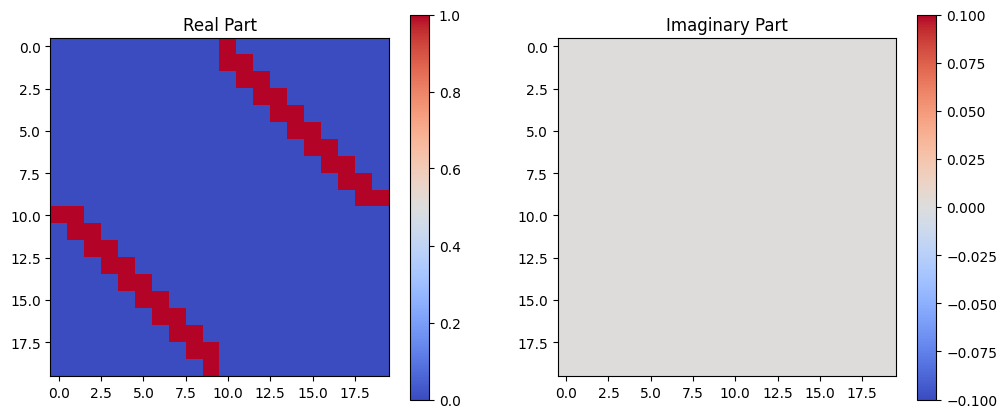

In [9]:
tb._visualise_matrix(tb.sublattice_connectivity)

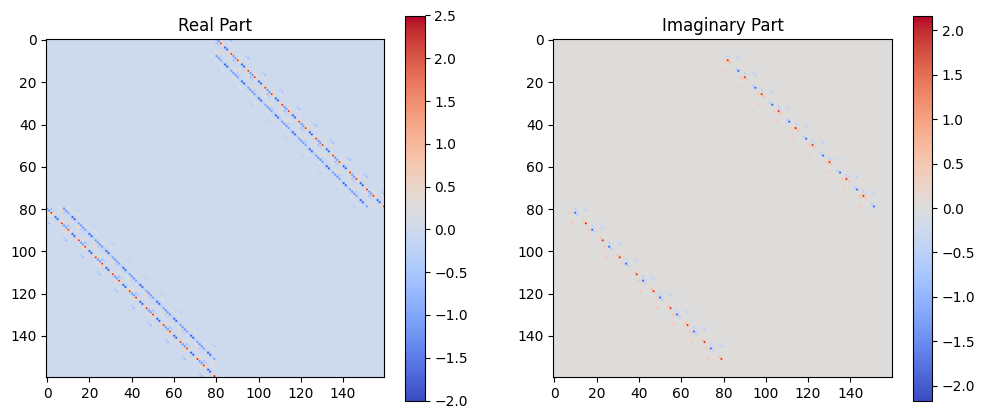

In [10]:
tb._visualise_matrix(tb.H)

In [11]:
problem.run(
    acceptor=False,
    H_type="real_space"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done.


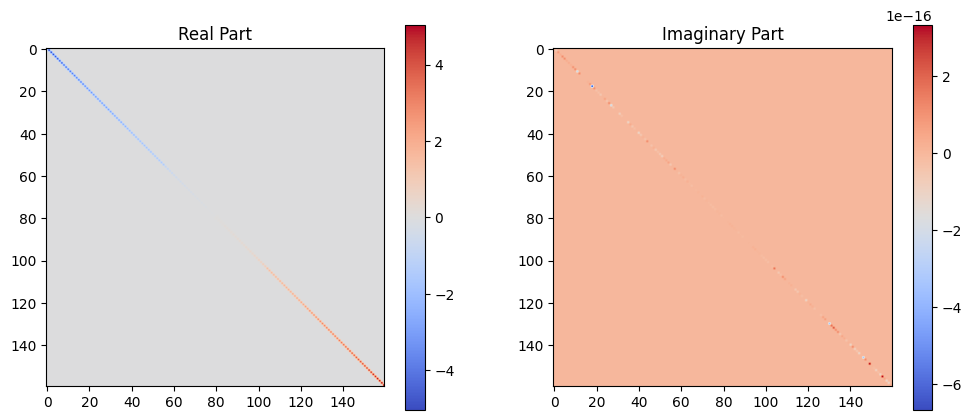

In [12]:
tb._visualise_matrix(tb.H_diag)

In [13]:
tb.E

array([-5.04314324, -5.04314324, -4.9014591 , -4.9014591 , -4.67165484,
       -4.67165484, -4.36415142, -4.36415142, -3.99618333, -3.99618333,
       -3.9553233 , -3.9553233 , -3.82229122, -3.82229122, -3.60387547,
       -3.60387547, -3.59733633, -3.59733633, -3.3049551 , -3.3049551 ,
       -3.22413763, -3.22413763, -2.98359199, -2.98359199, -2.93749022,
       -2.93749022, -2.93220749, -2.93220749, -2.88359593, -2.88359593,
       -2.74576274, -2.74576274, -2.54303446, -2.54303446, -2.49395921,
       -2.49395921, -2.30369784, -2.30369784, -2.06361836, -2.06361836,
       -2.        , -2.        , -1.87072497, -1.87072497, -1.77124123,
       -1.77124123, -1.73589833, -1.73589833, -1.68079238, -1.68079238,
       -1.55520094, -1.55520094, -1.54867346, -1.54867346, -1.4613641 ,
       -1.4613641 , -0.89008374, -0.89008374, -0.69384563, -0.69384563,
       -0.55957442, -0.55957442, -0.41884685, -0.41884685, -0.39849075,
       -0.39849075, -0.29892037, -0.29892037, -0.29117736, -0.29